In [26]:
from python_speech_features import mfcc

import matplotlib.pyplot as plt
from scipy.io import wavfile
import argparse
import os
from glob import glob
import numpy as np
import pandas as pd
from librosa.core import resample, to_mono
import librosa
from tqdm import tqdm
import wavio

In [27]:
def calc_fft(y,rate):
    n = len(y)
    freq = np.fft.rfftfreq(n,d=1/rate)
    Y = abs(np.fft.rfft(y)/n)
    return Y,freq

def plot_signals(signals):
    fig, axes = plt.subplots(nrows=2,ncols=4,sharex=False,sharey=True,figsize=(20,5))
    
    fig.suptitle("Time Series", size=16)
    
    i = 0
    
    for x in range(2):
        for y in range(4):
            axes[x,y].set_title(list(signals.keys())[i])
            axes[x,y].plot(list(signals.values())[i])
            axes[x,y].get_xaxis().set_visible(False)
            axes[x,y].get_yaxis().set_visible(False)
            i += 1

def plot_fft(fft):
    fig, axes = plt.subplots(nrows=2,ncols=4,sharex=False,sharey=True,figsize=(20,5))
    fig.suptitle("Fourier Transform", size=16)
    
    i = 0
    for x in range(2):
        for y in range(4):
            data = list(fft.values())[i]
            Y,freq = data[0], data[1]
            axes[x,y].set_title(list(fft.keys())[i])
            axes[x,y].plot(freq,Y)
            axes[x,y].get_xaxis().set_visible(False)
            axes[x,y].get_yaxis().set_visible(False)
            i += 1
            
def plot_mfccs(mfccs):
    fig, axes = plt.subplots(nrows=2,ncols=4,sharex=False,sharey=True,figsize=(20,5))
    fig.suptitle("Mel Frequency Cepstral Coefficients", size=16)
    
    i = 0
    for x in range(2):
        for y in range(4):
            axes[x,y].set_title(list(mfccs.keys())[i])
            axes[x,y].imshow(list(mfccs.values())[i],cmap="hot",interpolation="nearest")
            axes[x,y].get_xaxis().set_visible(False)
            axes[x,y].get_yaxis().set_visible(False)
            i += 1
            
            

In [28]:
data_dir = "../../../RAVDESS"
save_dir = "../../dataset/"
clean_dir = save_dir+"clean/"

df = pd.read_csv("audio_data.csv",index_col=[0])

In [34]:
# for file in df.index:
#     rate,signal = wavfile.read(clean_dir+file)
    
classes = list(df["emotion"].unique())
class_dist = df.groupby(["emotion"])["cleaned_length"].mean()

signals = dict()
fft = dict()
mfccs = dict()

for c in classes:
    filename = df[df["emotion"] == c].iloc[0,0]
    signal,rate = librosa.load(clean_dir+filename,sr=44100)
    signals[c] = signal
    fft[c] = calc_fft(signal,rate)
    mel = mfcc(signal[:rate],rate,numcep=13,nfilt=26,nfft=1200).T
    mfccs[c] = mel

In [35]:
filename

'08-01-01-01-01.wav'

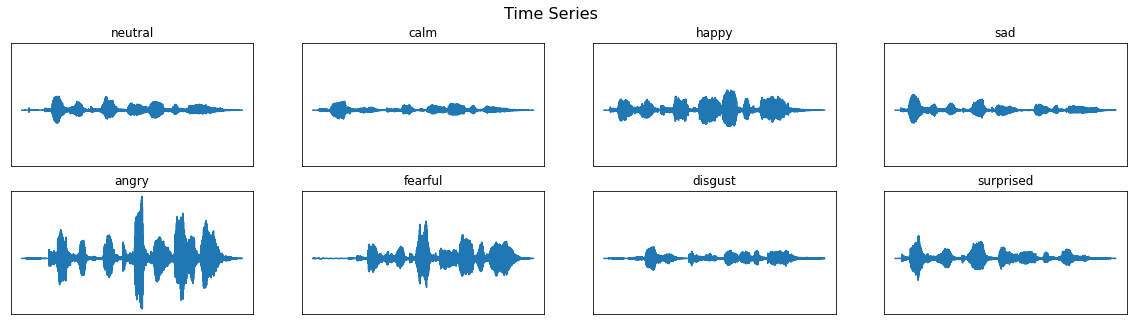

In [42]:
plot_signals(signals)
plt.savefig("audio_wave")

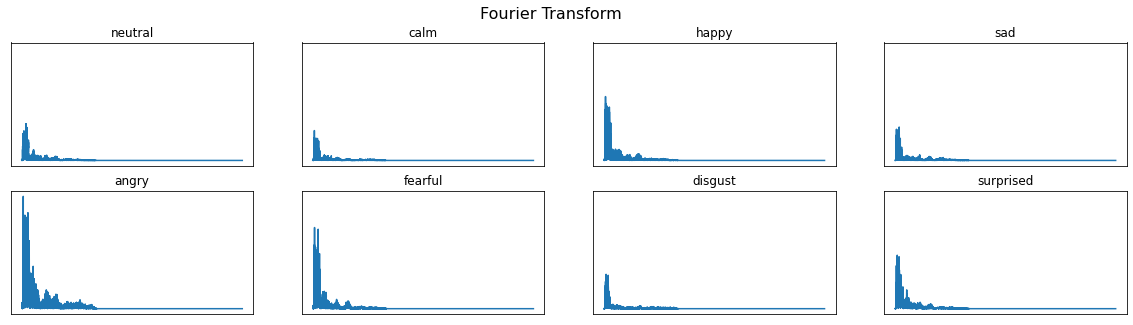

In [43]:
plot_fft(fft)
plt.savefig("fourier")

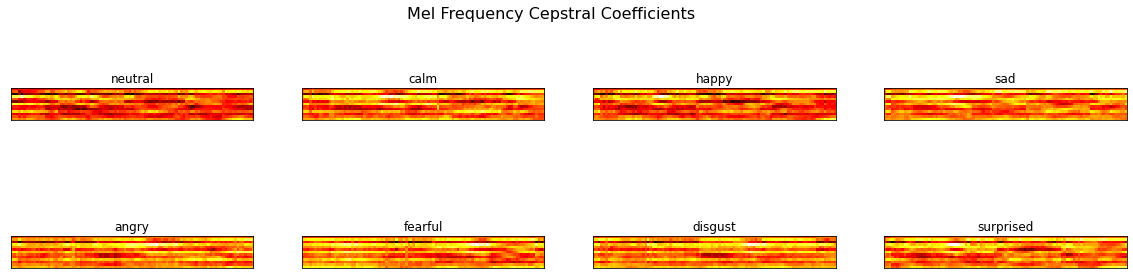

In [44]:
plot_mfccs(mfccs)
plt.savefig("mfccs")

In [47]:
lenemo = df.groupby("emotion")[["length","cleaned_length"]].mean()

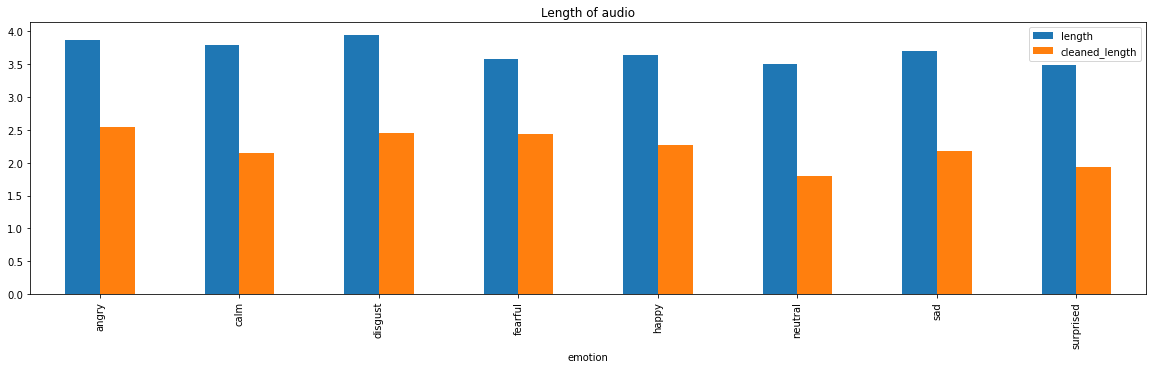

In [56]:
import seaborn as sns

lenemo.plot(kind="bar",figsize=(20,5),title="Length of audio")
plt.savefig("length")